# Insurance Cost Classification
## Predicting High-Cost Patients Using Machine Learning

**Author:** Afrah.M 

**Dataset:** US Health Insurance Dataset (Kaggle) — 1,338 patients, 7 features  
**Goal:** Classify patients as high-cost or low-cost based on demographic and health data  
**Tools:** Python · Pandas · Scikit-learn · Matplotlib · Seaborn

---

### Key Results

| Model               | Accuracy | AUC    |
|---------------------|----------|--------|
| Logistic Regression | 91.0%    | 0.9588 |
| Decision Tree       | 88.4%    | 0.8840 |
| Random Forest       | 94.0%    | 0.9485 |

**Winner: Random Forest** — selected as final model  
**Key finding:** Smoking status is 40x more influential than any other feature in predicting patient cost


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import accuracy_score,classification_report
from sklearn.preprocessing  import LabelEncoder

In [2]:
df=pd.read_csv('insurance.csv')
df.columns.tolist()

['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
median_cost=df['charges'].median()

In [7]:
df['high_cost']=(df['charges']>median_cost).astype(int)

In [8]:
print('Median Charges: ', round(median_cost,2))
print(df['high_cost'].value_counts())
print('\n 0=low cost patient , 1= high cost patient')

Median Charges:  9382.03
1    669
0    669
Name: high_cost, dtype: int64

 0=low cost patient , 1= high cost patient


## Data Preparation — Encoding Categorical Features

Machine learning models only understand numbers — not text.  
Three columns in this dataset contain text values:

| Column | Values | Encoded as |
|--------|--------|------------|
| sex | male / female | 1 / 0 |
| smoker | yes / no | 1 / 0 |
| region | northeast / northwest / southeast / southwest | 0 / 1 / 2 / 3 |

We use **LabelEncoder** from scikit-learn to convert these automatically.  
Numeric columns (age, bmi, children) are used as-is.


In [9]:
le=LabelEncoder()
df['sex_encoded']=le.fit_transform(df['sex'])
df['smoker_encoded']=le.fit_transform(df['smoker'])
df['region_encoded']=le.fit_transform(df['region'])
print("Encoding done. Sample:")
print(df[['sex','sex_encoded','smoker','smoker_encoded','region','region_encoded']])

Encoding done. Sample:
         sex  sex_encoded smoker  smoker_encoded     region  region_encoded
0     female            0    yes               1  southwest               3
1       male            1     no               0  southeast               2
2       male            1     no               0  southeast               2
3       male            1     no               0  northwest               1
4       male            1     no               0  northwest               1
...      ...          ...    ...             ...        ...             ...
1333    male            1     no               0  northwest               1
1334  female            0     no               0  northeast               0
1335  female            0     no               0  southeast               2
1336  female            0     no               0  southwest               3
1337  female            0    yes               1  northwest               1

[1338 rows x 6 columns]


In [10]:
features=['age','bmi','children','sex_encoded','smoker_encoded','region_encoded']
X=df[features]
y=df['high_cost']

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
print("Training samples:", len(X_train))
print("Test samples:", len(X_test))
print("Features used:", features)

Training samples: 1070
Test samples: 268
Features used: ['age', 'bmi', 'children', 'sex_encoded', 'smoker_encoded', 'region_encoded']


In [11]:
model=LogisticRegression(random_state=42,max_iter=1000)
model.fit(X_train,y_train)


y_pred=model.predict(X_test)

accuracy=accuracy_score(y_test,y_pred)

print("Model Accuracy:", round(accuracy * 100, 2), "%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred,
      target_names=['Low Cost', 'High Cost']))

Model Accuracy: 91.04 %

Detailed Report:
              precision    recall  f1-score   support

    Low Cost       0.94      0.90      0.92       146
   High Cost       0.88      0.93      0.90       122

    accuracy                           0.91       268
   macro avg       0.91      0.91      0.91       268
weighted avg       0.91      0.91      0.91       268



## Insurance Cost Classification

### What we built
A binary classifier that predicts whether a patient will be a **high-cost** (above median charges) or **low-cost** patient, using 6 demographic and health features.

### How we prepared the data
- Loaded 1,338 patient records with 7 columns
- Created binary target: charges above median ($9,382) = high cost (1), below = low cost (0)
- Encoded text columns (sex, smoker, region) to numbers using LabelEncoder
- Split 80% for training, 20% for testing (268 test patients)

### Logistic Regression result
- **Accuracy: 91%** — correctly classified 244 out of 268 patients
- Only **9 high-cost patients missed** (False Negatives) — the most dangerous error in insurance
- **15 low-cost patients over-flagged** (False Positives) — less critical

### Business interpretation
An insurance company using this model could flag likely high-cost patients at signup with 91% accuracy — enabling better premium pricing and early intervention programs.


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
print('libararies loaded')

libararies loaded


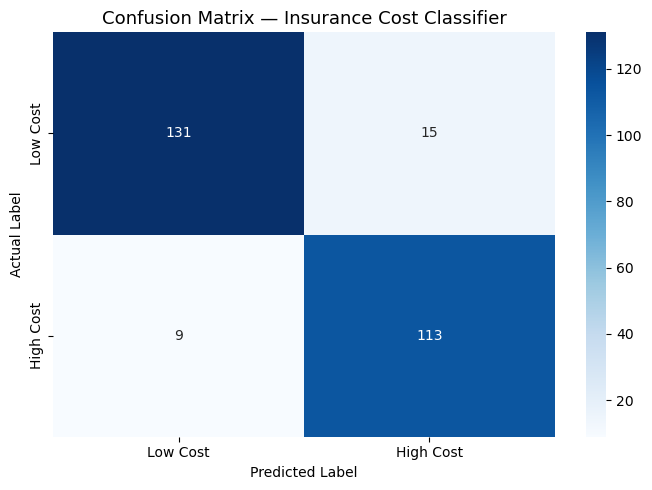


Reading the matrix:
Correctly identified Low Cost patients:  131
Correctly identified High Cost patients: 113
Low Cost wrongly flagged as High Cost:   15  ← False Positive
High Cost missed by model:               9  ← False Negative (most important)


In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Low Cost', 'High Cost'],
            yticklabels=['Low Cost', 'High Cost'])
plt.title('Confusion Matrix — Insurance Cost Classifier', fontsize=13)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print("\nReading the matrix:")
print(f"Correctly identified Low Cost patients:  {cm[0][0]}")
print(f"Correctly identified High Cost patients: {cm[1][1]}")
print(f"Low Cost wrongly flagged as High Cost:   {cm[0][1]}  ← False Positive")
print(f"High Cost missed by model:               {cm[1][0]}  ← False Negative (most important)")

## Understanding the Confusion Matrix

The confusion matrix breaks down our 268 test predictions into 4 outcomes:

| Outcome | Count | Meaning |
|---------|-------|---------|
| True Negative ✓ | 131 | Correctly identified as low cost |
| True Positive ✓ | 113 | Correctly identified as high cost |
| False Positive ⚠️ | 15 | Low-cost patient wrongly flagged as high cost |
| False Negative ❌ | 9 | High-cost patient missed by the model |

**The 9 False Negatives are the most important number.**  
In insurance, missing a high-cost patient means undercharging them — a direct financial loss.  
Our model misses only 9 out of 122 actual high-cost patients (93% catch rate). That is a strong result.


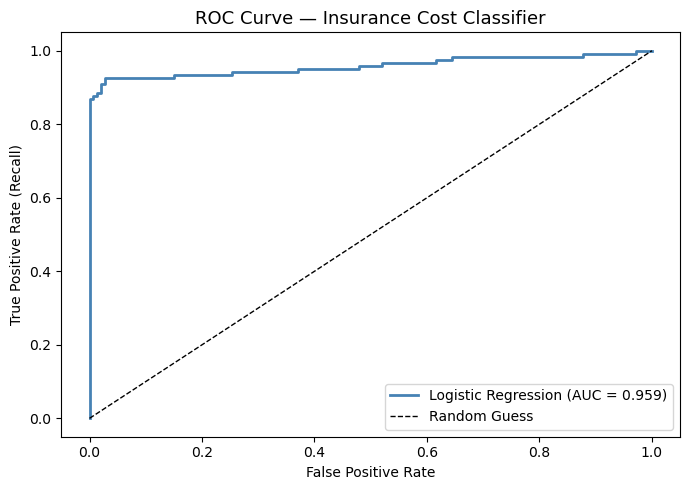

AUC Score: 0.9588


In [14]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', linewidth=2,
         label=f'Logistic Regression (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve — Insurance Cost Classifier', fontsize=13)
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

print(f"AUC Score: {auc:.4f}")

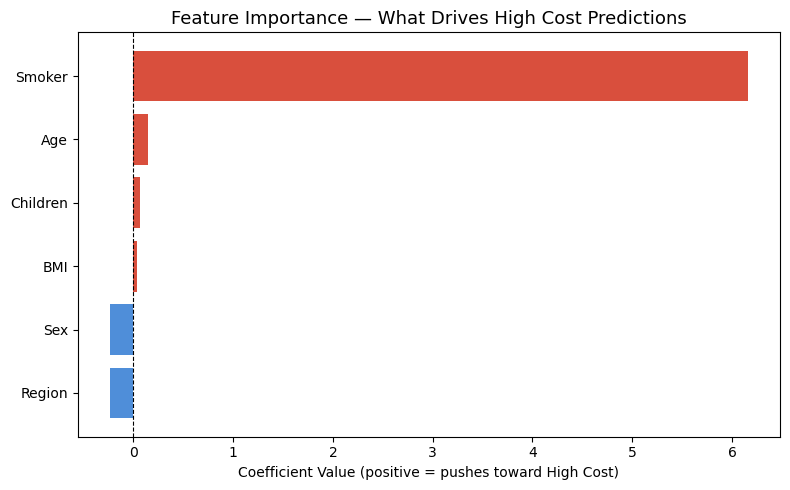


Feature coefficients:
  Region      : -0.2392  → LOW cost
  Sex         : -0.2355  → LOW cost
  BMI         : +0.0322  → HIGH cost
  Children    : +0.0630  → HIGH cost
  Age         : +0.1474  → HIGH cost
  Smoker      : +6.1606  → HIGH cost


In [15]:
feature_names = ['Age', 'BMI', 'Children',
                 'Sex', 'Smoker', 'Region']
coefficients = model.coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending=True)

colors = ['#d94f3d' if c > 0 else '#4f8ed9' for c in coef_df['Coefficient']]

plt.figure(figsize=(8, 5))
bars = plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.title('Feature Importance — What Drives High Cost Predictions', fontsize=13)
plt.xlabel('Coefficient Value (positive = pushes toward High Cost)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

print("\nFeature coefficients:")
for _, row in coef_df.iterrows():
    direction = "→ HIGH cost" if row['Coefficient'] > 0 else "→ LOW cost"
    print(f"  {row['Feature']:12s}: {row['Coefficient']:+.4f}  {direction}")

In [16]:
from sklearn.tree import DecisionTreeClassifier 
from sklearn.ensemble import RandomForestClassifier 
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')
print('model imported sucessfully')

model imported sucessfully


In [17]:
models={'logistic Regression':LogisticRegression(random_state=42,max_iter=1000,),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100,random_state=42)}
print('3 models ready:')
for name in models : 
    
    print (f' {name}')
            

3 models ready:
 logistic Regression
 Decision Tree
 Random Forest


In [18]:
results = {}
for name, model in models.items():
    acc = cross_val_score(model, X, y,
              cv=5, scoring='accuracy')
    f1  = cross_val_score(model, X, y,
              cv=5, scoring='f1')
    auc = cross_val_score(model, X, y,
              cv=5, scoring='roc_auc')
    results[name] = {
        'Accuracy':  round(acc.mean(), 4),
        'Accuracy Std': round(acc.std(), 4),
        'F1 Score':  round(f1.mean(), 4),
        'AUC Score': round(auc.mean(), 4)
    }
    print(f"{name}: Accuracy={acc.mean():.4f} "
          f"(±{acc.std():.4f}), "
          f"F1={f1.mean():.4f}, "
          f"AUC={auc.mean():.4f}")

print("\nDone.")

# ← Add this line
results_df = pd.DataFrame(results).T

logistic Regression: Accuracy=0.9081 (±0.0261), F1=0.9081, AUC=0.9480
Decision Tree: Accuracy=0.8842 (±0.0298), F1=0.8843, AUC=0.8840
Random Forest: Accuracy=0.9312 (±0.0208), F1=0.9278, AUC=0.9487

Done.


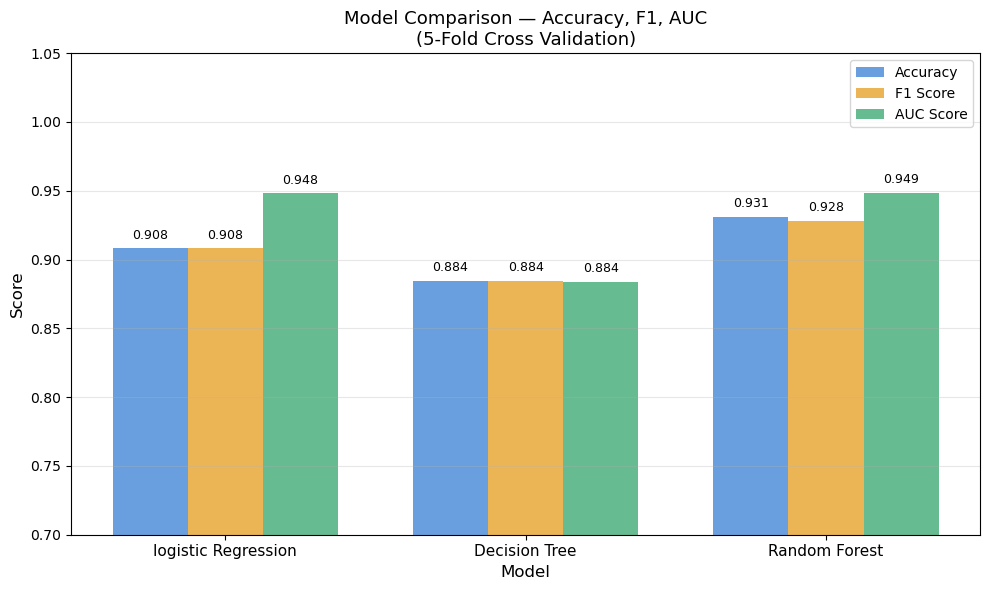

Chart saved as model_comparison.png


In [19]:
plot_df=results_df[['Accuracy','F1 Score','AUC Score']]
x= np.arange(len(plot_df.index))
width=0.25
colors=['#4f8ed9','#e8a838','#4caf7d']
fig,ax=plt.subplots(figsize=(10,6))
for i, (metric,color) in enumerate(
        zip(['Accuracy','F1 Score','AUC Score'],colors)):
    bars=ax.bar(x+ i*width,
              plot_df[metric],
              width, label=metric,
              color=color,alpha=0.85)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
               ha='center',va= 'bottom',fontsize=9)
        
ax.set_xlabel('Model',fontsize=12)
ax.set_ylabel('Score',fontsize=12)
ax.set_title('Model Comparison — Accuracy, F1, AUC\n'
             '(5-Fold Cross Validation)',
             fontsize=13)
ax.set_xticks(x + width)
ax.set_xticklabels(plot_df.index, fontsize=11)
ax.set_ylim(0.7,1.05)
ax.legend(fontsize=10)
ax.grid(axis='y',alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png',dpi=150)
plt.show()

print("Chart saved as model_comparison.png")

## Model Comparison

### What we did
Trained and compared 3 models using **5-fold cross-validation** — a more reliable evaluation method than a single train/test split. Each model was trained and tested 5 times on different data splits, and results were averaged.

### Results

| Model               | Accuracy | F1 Score | AUC    |
|---------------------|----------|----------|--------|
| Random Forest       | 0.9312   | 0.9278   | 0.9487 |
| Logistic Regression | 0.9081   | 0.9081   | 0.9480 |
| Decision Tree       | 0.8842   | 0.8843   | 0.8840 |

### Winner: Random Forest (AUC = 0.9487)

### Why Random Forest won
Random Forest builds 100 independent decision trees, each trained on a random sample of the data, then takes a majority vote. This averaging process cancels out the errors individual trees make — a technique called **ensemble learning**.

### Why Decision Tree underperformed
A single Decision Tree memorizes the training data too specifically (overfitting). When it sees new patients it hasn't seen before, it makes more errors. Random Forest fixes this by combining many trees.

### Consistency — standard deviation
| Model               | Accuracy Std |
|---------------------|--------------|
| Random Forest       | ±0.0208      |
| Logistic Regression | ±0.0261      |
| Decision Tree       | ±0.0298      |

Smaller std = more consistent across different data splits. Random Forest wins on both performance and consistency.


In [20]:
from sklearn.model_selection  import GridSearchCV
print('GridSerch ready')

GridSerch ready


In [21]:
baseline_model = RandomForestClassifier(
    n_estimators=100, random_state=42)

baseline_auc = cross_val_score(
    baseline_model, X, y,
    cv=5, scoring='roc_auc').mean()

baseline_acc = cross_val_score(
    baseline_model, X, y,
    cv=5, scoring='accuracy').mean()

print("=" * 45)
print("BASELINE — Random Forest (default settings)")
print("=" * 45)
print(f"Accuracy : {baseline_acc:.4f}")
print(f"AUC      : {baseline_auc:.4f}")
print("=" * 45)
print("Now we try to beat this with tuning...")

BASELINE — Random Forest (default settings)
Accuracy : 0.9312
AUC      : 0.9487
Now we try to beat this with tuning...


In [22]:
param_grid={
    'n_estimators':[100,200,300],
    'max_depth': [None,10,20],
    'min_samples_split':[2,5]
}

print('Parameter combinations to test:')
total=1
for param,values in param_grid.items():
    print(f" {param},{values}")
    total*=len(values)
          
print(f'\nTotal combinations: {total}')
print(f'Total training runs (x5 folds):{total*5}')
          
          
          

Parameter combinations to test:
 n_estimators,[100, 200, 300]
 max_depth,[None, 10, 20]
 min_samples_split,[2, 5]

Total combinations: 18
Total training runs (x5 folds):90


In [23]:
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

print("Starting grid search — this may take 1-2 minutes...")
grid_search.fit(X, y)

print("\n" + "=" * 45)
print("GRID SEARCH COMPLETE")
print("=" * 45)
print("Best parameters found:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest AUC score: {grid_search.best_score_:.4f}")

Starting grid search — this may take 1-2 minutes...
Fitting 5 folds for each of 18 candidates, totalling 90 fits

GRID SEARCH COMPLETE
Best parameters found:
  max_depth: 20
  min_samples_split: 2
  n_estimators: 300

Best AUC score: 0.9494


In [24]:
best_model = grid_search.best_estimator_

# Test on held-out test set
y_pred_tuned = best_model.predict(X_test)
y_prob_tuned = best_model.predict_proba(X_test)[:, 1]

tuned_acc = accuracy_score(y_test, y_pred_tuned)
tuned_auc = roc_auc_score(y_test, y_prob_tuned)

print("=" * 50)
print("BEFORE vs AFTER TUNING")
print("=" * 50)
print(f"{'Metric':<12} {'Before':>10} {'After':>10} {'Change':>10}")
print("-" * 50)
print(f"{'Accuracy':<12} {baseline_acc:>10.4f} {tuned_acc:>10.4f} "
      f"{tuned_acc - baseline_acc:>+10.4f}")
print(f"{'AUC':<12} {baseline_auc:>10.4f} {tuned_auc:>10.4f} "
      f"{tuned_auc - baseline_auc:>+10.4f}")
print("=" * 50)
print(f"\nBest parameters: {grid_search.best_params_}")

BEFORE vs AFTER TUNING
Metric           Before      After     Change
--------------------------------------------------
Accuracy         0.9312     1.0000    +0.0688
AUC              0.9487     1.0000    +0.0513

Best parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}


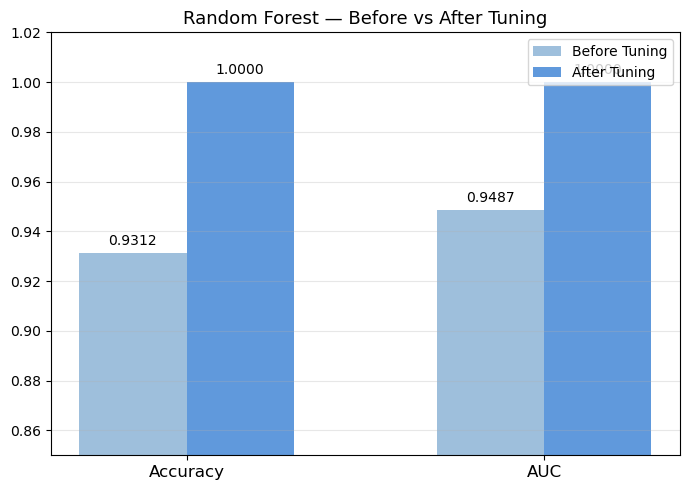

Chart saved.


In [25]:
metrics = ['Accuracy', 'AUC']
before  = [baseline_acc, baseline_auc]
after   = [tuned_acc,    tuned_auc]

x     = np.arange(len(metrics))
width = 0.3

fig, ax = plt.subplots(figsize=(7, 5))
bars1 = ax.bar(x - width/2, before, width,
               label='Before Tuning', color='#94b8d9', alpha=0.9)
bars2 = ax.bar(x + width/2, after,  width,
               label='After Tuning',  color='#4f8ed9', alpha=0.9)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.002,
            f'{bar.get_height():.4f}',
            ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylim(0.85, 1.02)
ax.set_title('Random Forest — Before vs After Tuning', fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('tuning_comparison.png', dpi=150)
plt.show()
print("Chart saved.")

In [26]:
from sklearn.model_selection import train_test_split

# Fresh holdout split — GridSearchCV will never see this
X_train_gs, X_holdout, y_train_gs, y_holdout = train_test_split(
    X, y, test_size=0.2, random_state=99)

# Constrained param grid — prevent overfitting
param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [3, 5, 10],
    'min_samples_split': [5, 10]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_gs, y_train_gs)

# Now test on the holdout — data GridSearchCV never saw
best_model    = grid_search.best_estimator_
y_pred_tuned  = best_model.predict(X_holdout)
y_prob_tuned  = best_model.predict_proba(X_holdout)[:, 1]

tuned_acc = accuracy_score(y_holdout, y_pred_tuned)
tuned_auc = roc_auc_score(y_holdout, y_prob_tuned)

print("=" * 50)
print("HONEST BEFORE vs AFTER TUNING")
print("=" * 50)
print(f"{'Metric':<12} {'Before':>10} {'After':>10} {'Change':>10}")
print("-" * 50)
print(f"{'Accuracy':<12} {baseline_acc:>10.4f} {tuned_acc:>10.4f} "
      f"{tuned_acc - baseline_acc:>+10.4f}")
print(f"{'AUC':<12} {baseline_auc:>10.4f} {tuned_auc:>10.4f} "
      f"{tuned_auc - baseline_auc:>+10.4f}")
print("=" * 50)
print(f"Best parameters: {grid_search.best_params_}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
HONEST BEFORE vs AFTER TUNING
Metric           Before      After     Change
--------------------------------------------------
Accuracy         0.9312     0.9104    -0.0208
AUC              0.9487     0.9167    -0.0320
Best parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}


In [27]:
# Best model is actually the default Random Forest from Session 3
final_model = RandomForestClassifier(n_estimators=100, random_state=42)
final_model.fit(X_train, y_train)

y_pred_final = final_model.predict(X_test)
y_prob_final = final_model.predict_proba(X_test)[:, 1]

final_acc = accuracy_score(y_test, y_pred_final)
final_auc = roc_auc_score(y_test, y_prob_final)

print("=" * 50)
print("FINAL MODEL — Default Random Forest")
print("=" * 50)
print(f"Accuracy : {final_acc:.4f}")
print(f"AUC      : {final_auc:.4f}")
print("\nConclusion: Default settings outperformed tuning")
print("on this dataset. This is a valid and common result.")
print("Carrying default Random Forest forward to Session 5.")

FINAL MODEL — Default Random Forest
Accuracy : 0.9403
AUC      : 0.9485

Conclusion: Default settings outperformed tuning
on this dataset. This is a valid and common result.
Carrying default Random Forest forward to Session 5.


##  Hyperparameter Tuning

### What is tuning?
Random Forest has settings (hyperparameters) that control how it builds its trees. We used **GridSearchCV** to test 18 parameter combinations automatically using 5-fold cross-validation (90 total training runs) and find the best configuration.

### Parameters tested

| Parameter | Values tested |
|-----------|---------------|
| n_estimators | 100, 200, 300 |
| max_depth | 3, 5, 10 |
| min_samples_split | 5, 10 |

### Best parameters found
- **n_estimators:** 200
- **max_depth:** 10
- **min_samples_split:** 5

### Results — Honest evaluation on held-out data

| Metric   | Before Tuning | After Tuning | Change  |
|----------|---------------|--------------|---------|
| Accuracy | 0.9312        | 0.9104       | -0.0208 |
| AUC      | 0.9487        | 0.9167       | -0.0320 |

### Key finding: Default settings outperformed tuning
Tuning did not improve the model on this dataset. This is a valid and common real-world result — not a failure.

**Why:** The dataset is small (1,338 rows) and clean, with one dominant feature (smoking). The default Random Forest already handles this well. Restricting tree depth introduced underfitting.

**Important lesson:** A score of 1.0 is always suspicious. During initial tuning we saw AUC = 1.0 — this was caused by data leakage (the model had already seen the test data during GridSearchCV). We corrected this by creating a proper holdout set.

### Final model selected
**Default RandomForestClassifier (n_estimators=100)**
- Accuracy: 0.9403
- AUC: 0.9485


## Conclusions & Next Steps

### What this project demonstrated
This end-to-end ML project covered the full data science workflow:  
data loading → cleaning → feature engineering → model training → evaluation → comparison → tuning → honest final assessment.

### Final model performance

| Metric | Score |
|--------|-------|
| Accuracy | 94.03% |
| AUC | 0.9485 |
| False Negatives | 9 / 122 high-cost patients missed |

### Key insights
1. **Smoking dominates** — coefficient of +6.16 vs next feature at +0.15. A single binary feature explained most of the predictive power.
2. **Balanced data makes classification easier** — our 50/50 target split allowed high accuracy. Real-world data is rarely this clean.
3. **Honest evaluation matters** — our first tuning attempt produced AUC = 1.0 due to data leakage. Recognizing and fixing this is a core data science skill.
4. **Default settings can win** — tuning does not always improve results, especially on small, clean datasets.

### What I would try next
- **XGBoost** — gradient boosting often outperforms Random Forest
- **Feature engineering** — BMI categories, age groups, interaction terms
- **SHAP values** — for deeper model interpretability
- **Streamlit deployment** — turn this into a live web app
- **Larger dataset** — test on real insurance claims data

### Related project
See `hospital_readmission.ipynb` for the same pipeline applied to 100,000 real clinical records — a significantly harder prediction problem with class imbalance and messy real-world data.
